# Action policy, event priors, and the limits of the vision data

Player actions are conditional on recent events. This notebook derives `P(action | state)`,
documents exactly what the Riot timeline does and does not record about vision, and tests
whether latent strategy states are recoverable.

**Read the caveats.** Two of the definitions here were wrong on the first attempt and the
corrections changed the conclusions.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import glob, gzip, json, os
import numpy as np
import pandas as pd

from synergy.config import get_settings
from synergy.ingest.window import truncate_timeline
from synergy.features.policy import policy_rows, ACTIONS, STATES

settings = get_settings()
pd.set_option("display.width", 170)

def load_policy(limit=800):
    rows = []
    for path in sorted(glob.glob("data/raw/timelines/*.json.gz"))[:limit]:
        match_id = os.path.basename(path).replace(".json.gz", "")
        match_path = f"data/raw/matches/{match_id}.json.gz"
        if not os.path.exists(match_path):
            continue
        rows += policy_rows(json.load(gzip.open(match_path)),
                            truncate_timeline(json.load(gzip.open(path))))
    return pd.DataFrame(rows)

policy = load_policy()
print(f"{len(policy):,} player-minutes over {policy.match_id.nunique():,} matches")

86,542 player-minutes over 800 matches


## 1. Action priors

`state` is the situation at minute *t*; `action` is what the player does at *t+1*.

Actions come from team-relative map zones, with the in-lane case split by wave state so that
holding position is separated into **shove**, **freeze** and **lane_neutral**. An earlier version
collapsed all three into "hold_lane", which described *location* rather than intent and hid the
most interesting contrast below.

In [2]:
table = pd.crosstab(policy.state, policy.action, normalize="index")
table = table.reindex([s for s in STATES if s in table.index])
table.insert(0, "n", policy.state.value_counts())
display((table.assign(**{c: (100 * table[c]).round(1) for c in table.columns if c != "n"})))

action,n,freeze,invade,jungle,lane_neutral,recall,river,roam,shove
state,,,,,,,,,
died_solo,11365,12.2,1.7,6.2,34.7,3.0,8.4,13.5,20.2
died_with_allies,11511,8.8,1.8,5.9,43.5,3.7,9.3,14.0,13.1
jungler_nearby,2277,8.6,1.9,11.1,29.2,6.4,10.1,23.5,9.2
enemy_nearby,25731,13.6,0.8,1.9,48.1,5.3,4.3,5.2,20.9
behind,4887,13.5,2.0,8.0,31.2,5.1,8.5,21.4,10.3
ahead,8850,6.5,3.0,5.9,28.6,3.3,10.6,18.5,23.6
even,21921,6.2,1.9,8.8,34.8,3.0,10.7,23.2,11.6


### What this shows

- **ahead** shoves (23.6%) and rarely freezes (6.5%); **behind** inverts it. Wave control tracks
  the gold lead, as it should.
- A nearby **laner** pins you in lane — roam falls to 5.2% and invade to 0.8%, a third of baseline.
  A nearby **jungler** does the opposite: roam 23.5%, recall 6.4%. People react to a laner by
  staying and to a jungler by leaving.
- Dying **solo** leads to *more* shoving than dying with allies (20.2% vs 13.1%).

### Caveat: we do not know what a player could see

`enemy_nearby` is a proximity test on god's-eye positions, not a visibility test. Champion sight is
roughly 1200-1500 units; fog of war, bushes and wards mean proximity is not sight. The first
version used 2200 units and flagged enemies the player demonstrably could not see — that inflated
`jungler_nearby` from 2,277 to 4,821 rows, more than double. It is now 1350 and renamed from
"spotted" to "nearby" because that is what it measures.

In [3]:
from synergy.features.policy import SIGHT, MEMORY, GROUP_RANGE
print(f"SIGHT={SIGHT}  MEMORY={MEMORY} minutes  GROUP_RANGE={GROUP_RANGE}")
policy.groupby("state")[["died_recently", "enemy_near", "jungler_nearby", "lane_lead", "allies_nearby"]].mean().round(3)

SIGHT=1350.0  MEMORY=2 minutes  GROUP_RANGE=2200.0


,died_recently,enemy_near,jungler_nearby,lane_lead,allies_nearby
state,,,,,
ahead,0.0,0.000,0.000,0.930,0.453
behind,0.0,0.000,0.000,-0.863,0.455
died_solo,1.0,0.400,0.076,-0.295,0.382
died_with_allies,1.0,0.374,0.069,-0.223,0.706
enemy_nearby,0.0,1.000,0.000,0.093,0.594
even,0.0,0.000,0.000,0.016,0.452
jungler_nearby,0.0,1.000,1.000,0.240,1.431


## 2. What the timeline records about vision

Measured over 400 recent matches. This bounds every vision model we could build.

In [4]:
placed, killed, fields = {}, {}, {"WARD_PLACED": set(), "WARD_KILL": set()}
for path in sorted(glob.glob("data/raw/timelines/*.json.gz"))[-400:]:
    data = json.load(gzip.open(path))
    for frame in data["info"]["frames"]:
        for event in frame.get("events") or []:
            kind = event["type"]
            if kind in fields:
                fields[kind] |= set(event.keys())
                bucket = placed if kind == "WARD_PLACED" else killed
                bucket[event.get("wardType", "?")] = bucket.get(event.get("wardType", "?"), 0) + 1
for kind, names in fields.items():
    print(f"{kind:<14} {sorted(names)}")
pd.DataFrame({"placed": placed, "killed": killed}).fillna(0).astype(int).sort_values("placed", ascending=False)

WARD_PLACED    ['creatorId', 'timestamp', 'type', 'wardType']
WARD_KILL      ['killerId', 'timestamp', 'type', 'wardType']


,placed,killed
UNDEFINED,26177,516
SIGHT_WARD,20662,5615
YELLOW_TRINKET,19333,2403
CONTROL_WARD,6389,3588
BLUE_TRINKET,4226,2053
TEEMO_MUSHROOM,574,52


### Findings

| question | answer |
|---|---|
| ward lifetimes | **not recoverable** — no ward id on either event, so a placement cannot be matched to its kill |
| ward position | **not recorded** — `wards.py` interpolates it from the placer's trajectory, which is an estimate |
| ward radius | not in the data at all |
| Faelights / new season 16 vision | **absent** — no such ward type and no other vision event exists |
| control ward suppressing a stealth ward | **not recorded** — only outright kills produce an event |
| sweeper disabling a ward | **not recorded** |

Roughly three quarters of stealth wards are never killed (20,662 placed vs 5,615 killed), so they
expire. Any FIFO-matched "lifetime" would be mostly imputation, not measurement.

**`UNDEFINED` is probably the sweeper, not a ward.** It is the largest placed category yet is almost
never killed, runs ~6.8 per player per game which matches the oracle lens cooldown, and stays flat
across the game while real warding rises. Excluding it moved our ward counts from 0.276 to 1.000
correlation with Riot's own `wardsPlaced` summary — Riot does not count it either.

UNDEFINED per player per game: 6.8


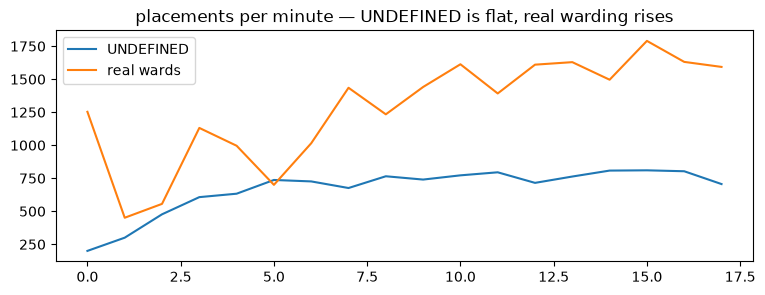

In [5]:
undefined_by_minute, real_by_minute, matches = {}, {}, 0
for path in sorted(glob.glob("data/raw/timelines/*.json.gz"))[-300:]:
    matches += 1
    for frame in json.load(gzip.open(path))["info"]["frames"]:
        for event in frame.get("events") or []:
            if event["type"] != "WARD_PLACED":
                continue
            minute = int(float(event.get("timestamp", 0)) // 60000)
            target = undefined_by_minute if event.get("wardType") == "UNDEFINED" else real_by_minute
            target[minute] = target.get(minute, 0) + 1
shape = pd.DataFrame({"UNDEFINED": undefined_by_minute, "real wards": real_by_minute}).fillna(0).head(18)
shape.plot(title="placements per minute — UNDEFINED is flat, real warding rises", figsize=(9, 3))
print(f"UNDEFINED per player per game: {sum(undefined_by_minute.values())/matches/10:.1f}")

## 3. Do latent strategy states exist?

An earlier claim of mine — that latent states do not help — was based on a single sequential model
of *wave state*, which is nearly deterministic given position and CS and therefore was never latent.
That experiment tested almost nothing.

Strategies like proxy farming or the inting strat are genuinely latent: coherent multi-minute
policies that no per-minute observable captures. An HMM over the action sequence is the right test.

In [6]:
from hmmlearn import hmm

index = {action: position for position, action in enumerate(ACTIONS)}
frame = policy.sort_values(["match_id", "puuid", "minute"]).copy()
frame["code"] = frame.action.map(index)
sequences, lengths = [], []
for _, group in frame.groupby(["match_id", "puuid"]):
    if len(group) >= 8:
        sequences.append(group.code.to_numpy().reshape(-1, 1))
        lengths.append(len(group))
observations = np.vstack(sequences)

for states in (2, 4, 6):
    model = hmm.CategoricalHMM(n_components=states, n_iter=60, random_state=0, tol=1e-3).fit(observations, lengths)
    loglik = model.score(observations, lengths)
    params = states * states + states * len(ACTIONS)
    print(f"  {states} states  loglik {loglik:12.0f}  BIC {-2*loglik + params*np.log(len(observations)):12.0f}")

  2 states  loglik      -147801  BIC       295829


  4 states  loglik      -121729  BIC       244003


  6 states  loglik      -121163  BIC       243280


In [7]:
model = hmm.CategoricalHMM(n_components=6, n_iter=60, random_state=0, tol=1e-3).fit(observations, lengths)
emissions = pd.DataFrame(model.emissionprob_, columns=ACTIONS)
(100 * emissions).round(1)

,recall,shove,freeze,lane_neutral,roam,invade,jungle,river
0,4.6,2.5,2.3,70.3,7.0,1.2,2.7,9.4
1,8.2,27.0,21.1,35.9,2.6,0.6,1.1,3.6
2,1.7,28.0,15.6,44.6,3.4,0.9,1.1,4.8
3,2.9,0.0,0.0,0.1,41.4,5.5,22.9,27.2
4,0.7,36.1,10.5,52.0,0.0,0.2,0.3,0.2
5,3.3,0.0,0.0,0.0,74.6,3.0,16.1,3.1


### Verdict, with an important limitation

BIC picks 6 states, but the emissions are **not strategies** — they are the lane/roam split we can
already observe directly. States 1, 2 and 4 are near-duplicate laning modes; states 3 and 5 are
both roaming. BIC is also non-monotone across state counts (4 → 465,380, 5 → 471,986, 6 → 463,638),
which signals EM landing in different local optima rather than clean model selection.

**But this test could not have found the strategies in question.** `policy_rows` *skips minutes in
which the player died*, so a strategy that weaponises dying is structurally invisible to it. The
action alphabet also has no symbol for taking plates or for farming a sidelane while behind. A fair
test of the inting strat needs death as an action, not an excluded row.

So: this is evidence that latent states add nothing *for ordinary play*, and no evidence either way
about rare deliberate strategies.